imports

In [2]:
import numpy as np
import pandas as pd


pd.options.display.float_format = "{:,.3f}".format

from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,KFold
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Question 1

In [3]:
models_df = pd.DataFrame()
models_df["Scenario"] = [1, 2, 3, 4, 5, 6]
models_df["ProblemType"] = [
    "Regression",
    "Classification",
    "Regression",
    "Classification",
    "Regression",
    "Clustering",
]

models_df["Algorithm"] = [
    "LinearRegression",
    "LogisticRegression",
    "KNNRegressor",
    "DecisionTreeClassifier",
    "KNNRegressor",
    "K-Means",
]

models_df["Metrics"] = ["MAE", "Accuracy", "R2score", "ConfusionMatrix", "MSE", "WCSS"]

display(models_df)

,Scenario,ProblemType,Algorithm,Metrics
0,1,Regression,LinearRegression,MAE
1,2,Classification,LogisticRegression,Accuracy
2,3,Regression,KNNRegressor,R2score
3,4,Classification,DecisionTreeClassifier,ConfusionMatrix
4,5,Regression,KNNRegressor,MSE
5,6,Clustering,K-Means,WCSS


# Reason

In [4]:
# A) Because Clustering does not have True label and Accuracy and Classification metrics need True label to measure score!
# B) Because if a bad model predicts all observes as Normal
# TN will be nice and Accuracy Measure  "TN+TP / Total"  So Big TN will show accuracy score so high.
# C) A Regression Problem label and predict will be "Continues Value" and in this case
# we could measure variance of fitted line(R2) or mean error (MAE,MSE)
# But in Classification we have limited classes and output type is Discrete
# So We most check the ratio of correct and incorrect classified observations(Precision,Recall,ConfusionMatrix,F1-score)

# Question 2

In [5]:
len(
    [
        59.7,
        94.2,
        82.2,
        83.1,
        72.2,
        62.8,
        43.3,
        97.3,
        78.1,
        88.6,
        61.2,
        86.6,
        97.9,
        59.2,
        43.3,
        72.4,
        48.4,
        74.1,
        66.6,
        54.6,
        67.3,
        55.0,
        2,
        68.7,
        54.5,
        67.1,
        69.7,
        47.2,
        62.9,
        81.4,
        50.7,
        64.3,
        53.8,
        44.5,
        88.3,
        100.0,
        67.1,
        36.4,
        59.6,
        85.4,
        80.9,
        68.6,
        69.8,
        35.0,
        1,
        00.0,
        60.6,
        82.2,
        50.8,
        77.4,
        55.7,
        32.3,
        100.0,
        77.8,
        76.1,
        74.3,
        74.4,
        100.0,
        55.3,
        56.6,
        44.6,
        47.0,
    ]
)

62

In [6]:
quiz_data = pd.DataFrame(
    {
        "study_hours": [
            4.8,
            11.4,
            8.9,
            7.4,
            2.3,
            2.3,
            1.2,
            10.5,
            7.4,
            8.6,
            0.7,
            11.7,
            10.1,
            2.9,
            2.6,
            2.6,
            4.0,
            6.5,
            5.5,
            3.8,
            7.5,
            2.1,
            3.9,
            4.7,
            5.7,
            9.5,
            2.8,
            6.0,
            4,
            7.3,
            1.0,
            7.5,
            2.5,
            1.2,
            11.4,
            11.6,
            9.8,
            4.0,
            1.6,
            8.4,
            5.6,
            1.9,
            6.2,
            0.9,
            11.0,
            3.5,
            8.1,
            4.1,
            6.5,
            6.8,
            2.6,
            11.7,
            9.4,
            11.3,
            10.8,
            7.0,
            4,
            11.1,
            1.5,
            2.8,
        ],
        "videos_watched": [
            15,
            12,
            17,
            14,
            20,
            23,
            24,
            12,
            8,
            14,
            12,
            0,
            24,
            6,
            8,
            23,
            0,
            11,
            7,
            23,
            10,
            18,
            16,
            7,
            2,
            2,
            0,
            4,
            9,
            6,
            8,
            6,
            8,
            7,
            11,
            1,
            0,
            15,
            22,
            22,
            23,
            4,
            2,
            11,
            7,
            21,
            2,
            0,
            2,
            4,
            14,
            13,
            2,
            0,
            4,
            22,
            13,
            6,
            8,
            14,
        ],
        "practice_solved": [
            14,
            25,
            12,
            31,
            38,
            31,
            3,
            29,
            36,
            22,
            38,
            14,
            28,
            35,
            12,
            31,
            6,
            21,
            27,
            1,
            5,
            27,
            27,
            19,
            29,
            10,
            27,
            24,
            38,
            32,
            0,
            26,
            12,
            2,
            38,
            5,
            7,
            26,
            8,
            36,
            32,
            23,
            14,
            31,
            31,
            23,
            11,
            38,
            1,
            2,
            36,
            16,
            1,
            1,
            27,
            22,
            36,
            31,
            32,
            0,
        ],
        "quiz_score": [
            59.7,
            94.2,
            82.2,
            83.1,
            72.2,
            62.8,
            43.3,
            97.3,
            78.1,
            88.6,
            61.2,
            86.6,
            97.9,
            59.2,
            43.3,
            72.4,
            48.4,
            74.1,
            66.6,
            54.6,
            67.3,
            55.0,
            2,
            68.7,
            54.5,
            67.1,
            69.7,
            47.2,
            62.9,
            81.4,
            50.7,
            64.3,
            53.8,
            44.5,
            88.3,
            100.0,
            67.1,
            36.4,
            59.6,
            85.4,
            80.9,
            68.6,
            69.8,
            35.0,
            1,
            00.0,
            60.6,
            82.2,
            50.8,
            77.4,
            55.7,
            32.3,
            100.0,
            77.8,
            76.1,
            74.3,
            74.4,
            100.0,
            55.3,
            56.6,
        ],
    }
)

display(quiz_data.head())
display(quiz_data.describe())
display(quiz_data.info())

,study_hours,videos_watched,practice_solved,quiz_score
0,4.800,15,14,59.700
1,11.400,12,25,94.200
2,8.900,17,12,82.200
3,7.400,14,31,83.100
4,2.300,20,38,72.200


,study_hours,videos_watched,practice_solved,quiz_score
count,60.000,60.000,60.000,60.000
mean,5.908,10.317,21.000,64.675
std,3.467,7.525,12.498,22.324
min,0.700,0.000,0.000,0.000
25%,2.750,4.000,10.750,54.575
50%,5.650,8.500,24.500,67.100
75%,8.675,15.000,31.000,78.800
max,11.700,24.000,38.000,100.000


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   study_hours      60 non-null     float64
 1   videos_watched   60 non-null     int64  
 2   practice_solved  60 non-null     int64  
 3   quiz_score       60 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0 KB


None

In [7]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    quiz_data.iloc[:, :-1], quiz_data.iloc[:, -1], test_size=0.2, random_state=42
)

print(f"Shape of Xtrain: {Xtrain.shape}")
print(f"Shape of ytrain: {ytrain.shape}")
print(f"Shape of Xtest: {Xtest.shape}")
print(f"Shape of ytest: {ytest.shape}")

Shape of Xtrain: (48, 3)
Shape of ytrain: (48,)
Shape of Xtest: (12, 3)
Shape of ytest: (12,)


In [8]:
linear_reg = LinearRegression()
linear_reg.fit(Xtrain, ytrain)

ypred = linear_reg.predict(Xtest)

,Coefficient
study_hours,2.503
videos_watched,-0.044
practice_solved,0.102


,Value
R2 Score,0.330
MSE,406.600
MAE,12.915


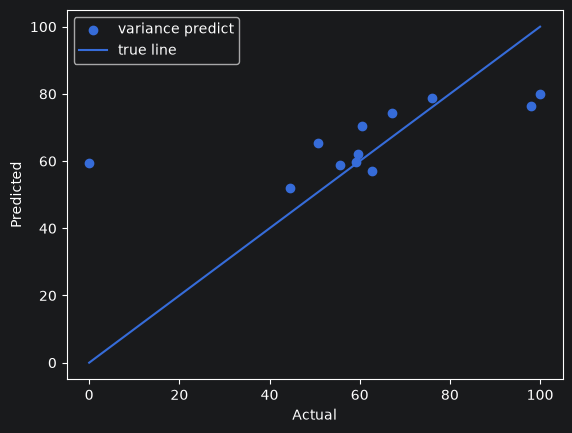

In [9]:
mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
r2s = r2_score(ytest, ypred)
coef_df = pd.DataFrame(
    {
        "Coefficient": linear_reg.coef_,
    },
    index=[quiz_data.columns[:-1]],
)
results_df = pd.DataFrame(
    {
        "R2 Score": r2s,
        "MSE": mse,
        "MAE": mae,
    },
    index=["Value"],
).T
display(coef_df)
display(results_df)
# print(f"{"R2 Score":<10}:{r2s:>3.2f}")
# print(f"{"MSE":<10}:{mse:>3.2f}")
# print(f"{"MAE":<10}:{mae:>3.2f}")


plt.scatter(ytest, ypred, label="variance predict")
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], label="true line")
plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [10]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    quiz_data.iloc[:, :-2], quiz_data.iloc[:, -1], test_size=0.2, random_state=42
)

print(f"Shape of Xtrain: {Xtrain.shape}")
print(f"Shape of ytrain: {ytrain.shape}")
print(f"Shape of Xtest: {Xtest.shape}")
print(f"Shape of ytest: {ytest.shape}")

linear_reg = LinearRegression()
linear_reg.fit(Xtrain, ytrain)

ypred = linear_reg.predict(Xtest)

Shape of Xtrain: (48, 2)
Shape of ytrain: (48,)
Shape of Xtest: (12, 2)
Shape of ytest: (12,)


,Coefficient
study_hours,2.489
videos_watched,-0.019


,Value
R2 Score,0.301
MSE,423.854
MAE,13.502


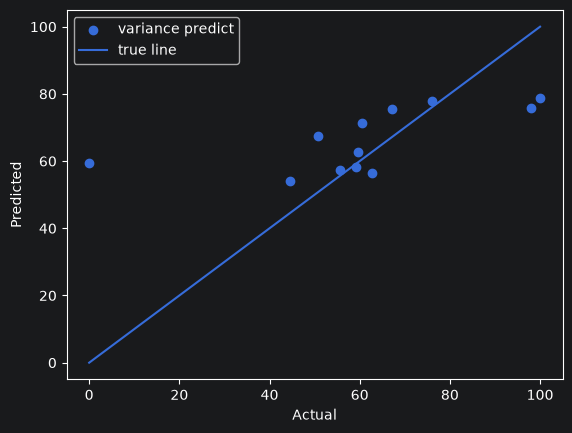

In [11]:
mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
r2s = r2_score(ytest, ypred)
coef_df = pd.DataFrame(
    {
        "Coefficient": linear_reg.coef_,
    },
    index=[quiz_data.columns[:-2]],
)
results_df = pd.DataFrame(
    {
        "R2 Score": r2s,
        "MSE": mse,
        "MAE": mae,
    },
    index=["Value"],
).T
display(coef_df)
display(results_df)
# print(f"{"R2 Score":<10}:{r2s:>3.2f}")
# print(f"{"MSE":<10}:{mse:>3.2f}")
# print(f"{"MAE":<10}:{mae:>3.2f}")


plt.scatter(ytest, ypred, label="variance predict")
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], label="true line")
plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### After removing the third feature, the R² score decreased, while the MSE and MAE increased.

# Question 3

,visits_per_month,avg_session_min,days_since_last_visit,has_personal_trainer,churned
0,6,51.100,8,1,0
1,5,40.800,10,1,0
2,0,15.400,21,0,1
3,4,74.200,1,1,0
4,15,42.200,10,1,0


,visits_per_month,avg_session_min,days_since_last_visit,has_personal_trainer,churned
count,90.000,90.000,90.000,90.000,90.000
mean,9.678,44.633,11.611,0.622,0.156
std,5.850,17.761,12.077,0.488,0.364
min,0.000,11.000,0.000,0.000,0.000
25%,5.000,31.425,4.000,0.000,0.000
50%,10.000,47.800,9.000,1.000,0.000
75%,15.000,56.775,13.000,1.000,0.000
max,19.000,74.300,58.000,1.000,1.000


<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   visits_per_month       90 non-null     int64  
 1   avg_session_min        90 non-null     float64
 2   days_since_last_visit  90 non-null     int64  
 3   has_personal_trainer   90 non-null     int64  
 4   churned                90 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 3.6 KB


None

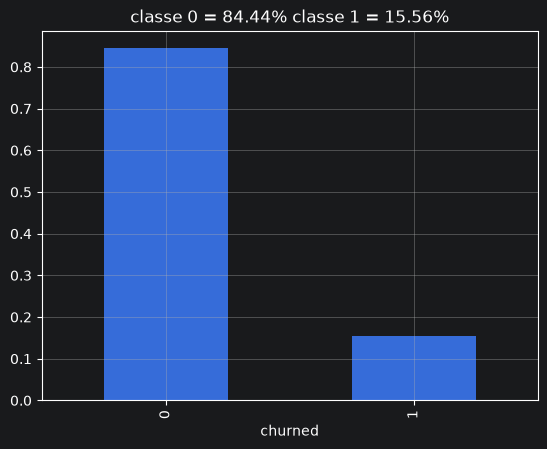

In [12]:
gym_data = pd.DataFrame(
    {
        "visits_per_month": [
            6,
            5,
            0,
            4,
            15,
            12,
            18,
            4,
            17,
            6,
            6,
            0,
            11,
            18,
            8,
            0,
            16,
            12,
            16,
            14,
            17,
            13,
            3,
            19,
            13,
            15,
            15,
            4,
            0,
            16,
            18,
            15,
            0,
            11,
            4,
            0,
            0,
            5,
            17,
            15,
            17,
            10,
            0,
            6,
            5,
            10,
            14,
            4,
            13,
            19,
            6,
            7,
            17,
            4,
            5,
            17,
            3,
            7,
            0,
            12,
            19,
            12,
            1,
            14,
            13,
            9,
            11,
            6,
            8,
            19,
            12,
            8,
            10,
            17,
            14,
            5,
            12,
            7,
            2,
            4,
            14,
            12,
            9,
            16,
            11,
            9,
            3,
            10,
            4,
            16,
        ],
        "avg_session_min": [
            51.1,
            40.8,
            15.4,
            74.2,
            42.2,
            44.3,
            26.8,
            54.0,
            66.4,
            56.7,
            25.1,
            18.6,
            66.3,
            73.9,
            48.1,
            13.9,
            40.4,
            27.1,
            49.5,
            51.0,
            42.2,
            51.2,
            13.4,
            43.6,
            54.7,
            49.9,
            74.3,
            47.5,
            11.3,
            25.4,
            51.7,
            47.2,
            12.6,
            32.4,
            54.5,
            11.0,
            13.1,
            28.6,
            33.4,
            45.6,
            38.9,
            64.9,
            24.3,
            58.1,
            42.0,
            72.3,
            66.1,
            53.3,
            64.1,
            25.1,
            68.6,
            52.4,
            49.4,
            63.6,
            63.1,
            62.6,
            17.9,
            71.0,
            13.2,
            50.1,
            59.8,
            48.8,
            22.6,
            27.8,
            49.8,
            30.3,
            51.6,
            56.8,
            33.3,
            54.3,
            31.1,
            52.9,
            35.4,
            65.0,
            37.1,
            47.1,
            73.8,
            59.7,
            12.0,
            59.5,
            72.2,
            52.2,
            62.6,
            51.2,
            37.1,
            46.4,
            16.8,
            39.4,
            37.3,
            42.7,
        ],
        "days_since_last_visit": [
            8,
            10,
            21,
            1,
            10,
            11,
            8,
            1,
            14,
            3,
            7,
            41,
            1,
            6,
            14,
            20,
            8,
            7,
            12,
            14,
            2,
            14,
            23,
            12,
            7,
            4,
            10,
            5,
            46,
            4,
            11,
            4,
            58,
            11,
            10,
            26,
            49,
            4,
            1,
            4,
            5,
            13,
            5,
            43,
            13,
            10,
            7,
            1,
            5,
            2,
            13,
            14,
            11,
            1,
            12,
            3,
            7,
            27,
            3,
            25,
            9,
            1,
            5,
            27,
            11,
            8,
            4,
            9,
            0,
            9,
            5,
            12,
            10,
            5,
            1,
            4,
            2,
            12,
            10,
            55,
            1,
            0,
            8,
            14,
            13,
            8,
            3,
            11,
            34,
            12,
        ],
        "has_personal_trainer": [
            1,
            1,
            0,
            1,
            1,
            0,
            1,
            1,
            1,
            1,
            1,
            0,
            1,
            0,
            1,
            0,
            1,
            1,
            0,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            0,
            1,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            1,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            1,
            0,
            1,
            1,
            1,
            1,
            1,
            0,
            1,
            0,
            1,
            0,
            1,
            1,
            1,
            1,
            1,
            1,
            0,
            1,
            0,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            0,
            1,
            0,
            1,
            0,
            1,
            1,
            0,
            1,
            1,
            0,
            1,
            1,
            0,
            0,
        ],
        "churned": [
            0,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            1,
            0,
            0,
            1,
            1,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            1,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0,
        ],
    }
)

display(gym_data.head())
display(gym_data.describe())
display(gym_data.info())
gym_data["churned"].value_counts(normalize=True).plot(kind="bar")
plt.title(
f"classe 0 = {gym_data["churned"].value_counts(normalize=True).values[0]*100:.2f}% \
classe 1 = {gym_data["churned"].value_counts(normalize=True).values[1]*100:.2f}%"
)
plt.grid()
plt.show()

In [13]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    gym_data.iloc[:, :-1],
    gym_data.iloc[:, -1],
    stratify=gym_data.iloc[:, -1],
    test_size=0.2,
    random_state=42,
)
print(f"{"Xtrain.shape":<15}| {Xtrain.shape}")
print(f"{"ytrain.shape":<15}| {ytrain.shape}")
print(f"{"Xtest.shape":<15}| {Xtest.shape}")
print(f"{"ytest.shape":<15}| {ytest.shape}")

Xtrain.shape   | (72, 4)
ytrain.shape   | (72,)
Xtest.shape    | (18, 4)
ytest.shape    | (18,)


In [14]:
scaler = StandardScaler()
Xtrain_s = scaler.fit_transform(Xtrain)
Xtest_s = scaler.transform(Xtest)

log_reg = LogisticRegression()
log_reg.fit(Xtrain_s, ytrain)

ypred = log_reg.predict(Xtest_s)

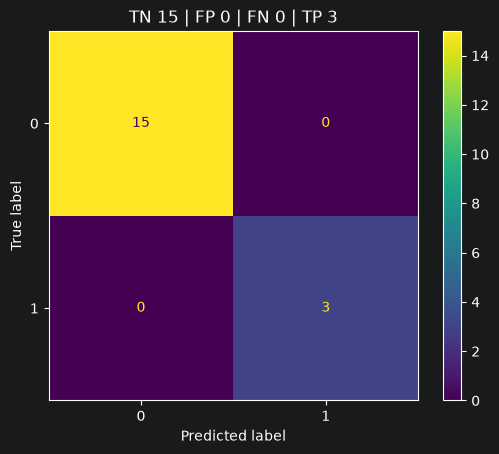

,Values
Precision,1.000
Recall,1.000
F1-score,1.000
Accuracy,1.000


In [15]:
cm = confusion_matrix(ytest, ypred)
TN,FP,FN,TP = cm.flatten()
dsp = ConfusionMatrixDisplay(cm, display_labels=log_reg.classes_)
dsp.plot()
plt.title(f"TN {TN} | FP {FP} | FN {FN} | TP {TP}")
plt.show()

metrics_df = pd.DataFrame({
    "Values":[precision_score(ytest,ypred),recall_score(ytest,ypred),f1_score(ytest,ypred),accuracy_score(ytest,ypred)]
},    index=['Precision','Recall','F1-score','Accuracy']
)
display(metrics_df)

# Reason

In [16]:
# Classes distribution are 84% for class 0(not churned) 16% for class 1(churned)
# Thus the dataset is unbalanced if a bad model predicts every Xs as normal (class 0) accuracy will be near to 84
# because TN will be 84 percent.

# in this case all metrics for this model on this data set are 100 %
# because model fitted on train data very nice and predicted on test data very good.
# However, In This problem (predict churn or not ) FN is more important than FP So Recall(TP/TP+FN) is more effective.

# FN cost is bigger than FP for this problem

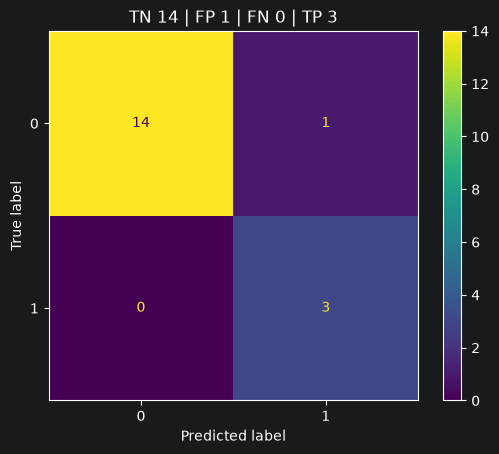

,Values
Precision,0.750
Recall,1.000
F1-score,0.857
Accuracy,0.944


In [17]:
predict_probability = log_reg.predict_proba(Xtest_s)[:,1]
threshold = 0.3
new_predict = predict_probability > threshold


cm = confusion_matrix(ytest, new_predict)
TN,FP,FN,TP = cm.flatten()
dsp = ConfusionMatrixDisplay(cm, display_labels=log_reg.classes_)
dsp.plot()
plt.title(f"TN {TN} | FP {FP} | FN {FN} | TP {TP}")
plt.show()

metrics_df = pd.DataFrame({
    "Values":[precision_score(ytest,new_predict),recall_score(ytest,new_predict),f1_score(ytest,new_predict),accuracy_score(ytest,new_predict)]
},    index=['Precision','Recall','F1-score','Accuracy']
)
display(metrics_df)

set threshold at 0.3 just destroyed precision because all metrics were already 100%

# Question 4

In [18]:
light_data = pd.DataFrame()
light_data["days_before_flight"] = [26,64,81,82,56,14,77,34,72,83,25,49,33,46,5,35,13,2,75,38,85,82,25,18,68,71,44,65,80,24,28,71,1,
1,58,28,45,15,8,56,80,65,41,28,6,54,72,51,60,2,4,9,88,82,69]
light_data["distance_km"] = [575,2245,1234,3510,2458,1752,564,1229,685,1291,4245,718,319,3456,2142,743,793,1140,1362,2,
259,419,4258,4171,3104,3216,3504,2533,2669,2088,4486,930,4032,662,3818,4016,3190,4378,198,
5,1231,2813,2866,4244,2077,614,3949,1424,4340,1105,1929,2600,3550,4009,2305]
light_data["num_stops"] = [0,1,0,1,0,0,2,2,2,0,0,2,0,1,1,1,0,1,2,2,2,2,0,1,2,2,0,0,2,1,1,2,0,1,1,2,2,1,2,2,1,1,0,2,1,2,1,0,1,0,2,0,2,
2,1]
light_data["ticket_price_usd"] = [335,380,275,391,458,431,61,331,133,233,683,214,308,506,476,298,402,480,162,390,63,425,705,5,
69,368,400,474,375,233,703,354,443,380,492,571,475,663,495,207,287,401,595,453,357,544,189,
552,254,476,609,611,456,224,246]

display(light_data.head())
display(light_data.describe())
display(light_data.info())


,days_before_flight,distance_km,num_stops,ticket_price_usd
0,26,575,0,335
1,64,2245,1,380
2,81,1234,0,275
3,82,3510,1,391
4,56,2458,0,458


,days_before_flight,distance_km,num_stops,ticket_price_usd
count,55.000,55.000,55.000,55.000
mean,45.345,"2,208.273",1.091,383.655
std,27.909,"1,425.808",0.823,167.897
min,1.000,2.000,0.000,5.000
25%,24.500,861.500,0.000,264.500
50%,46.000,"2,142.000",1.000,391.000
75%,71.000,"3,507.000",2.000,478.000
max,88.000,"4,486.000",2.000,705.000


<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   days_before_flight  55 non-null     int64
 1   distance_km         55 non-null     int64
 2   num_stops           55 non-null     int64
 3   ticket_price_usd    55 non-null     int64
dtypes: int64(4)
memory usage: 1.8 KB


None

In [19]:
Xtrain,Xtest,ytrain,ytest = train_test_split(
    light_data.iloc[:,:-1].to_numpy(),light_data.iloc[:,-1].to_numpy(),test_size=0.2,random_state=42
)
print(
f"Xtrain.shape {Xtrain.shape}\n\
Xtest.shape {Xtest.shape}\n\
ytrain.shape {ytrain.shape}\n\
ytest.shape {ytest.shape}"
)

scaler = StandardScaler()
Xtrain_s = scaler.fit_transform(Xtrain)
Xtest_s = scaler.transform(Xtest)


Xtrain.shape (44, 3)
Xtest.shape (11, 3)
ytrain.shape (44,)
ytest.shape (11,)


In [20]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(Xtrain_s, ytrain)
ypred = knn_reg.predict(Xtest_s)

In [21]:
knn_r2 = r2_score(ytest,ypred)
knn_mae = mean_absolute_error(ytest,ypred)
knn_mse = mean_squared_error(ytest,ypred)

print(f"{"R2 score":<10}{knn_r2:.3f}\n{"MAE":<10}{knn_mae:.3f}\n{"MSE":<10}{knn_mse:.3f}")

R2 score  -2.243
MAE       82.527
MSE       9472.287


In [22]:
def knn_fitter(Xtrain,Xtest,ytrain,ytest,k=3):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(Xtrain, ytrain)
    predict = r2_score(ytest,model.predict(Xtest))
    return predict

<Axes: xlabel='K'>

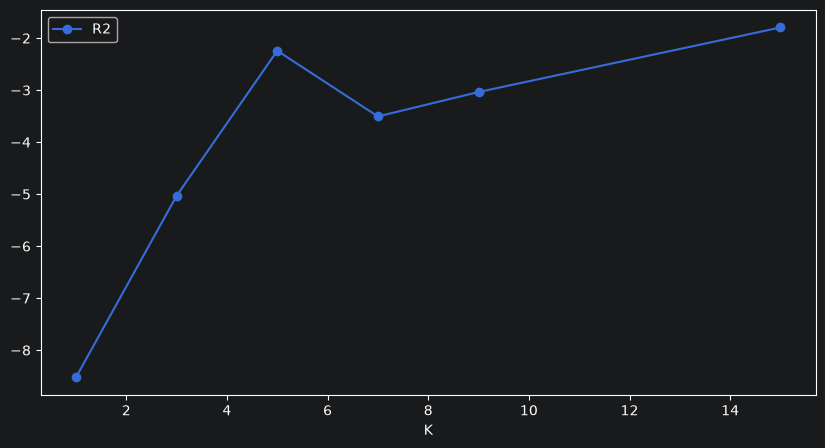

In [23]:
k = [1,3,5,7,9,15]
r2 = []
for n_neighbor in k:
    r2.append(knn_fitter(Xtrain_s,Xtest_s,ytrain,ytest,n_neighbor))
results = pd.DataFrame({
    "K":k,
    "R2":r2,
})
results.plot(kind="line",x="K",y="R2",figsize=(10,5),marker="o")

In [24]:
# best estimator
knn_best_reg = KNeighborsRegressor(n_neighbors=15)
knn_best_reg.fit(Xtrain_s, ytrain)

X_new = scaler.transform([[20,2000,1]])
ypred_new = knn_best_reg.predict(X_new)
print(f"New observe predict {ypred_new[0]:.2f}")

New observe predict 410.33


# Reason

In [25]:
# to find best value for K we should test a list of different values of k and check the result

# If k = 1 overfitting appears and model will be very sensitive to train datas
# If K = n_samples underfitting appears the model will return Mean as predicted value

# KNN is a distance base algorithm and Euclidean distance measures distance between points
# a feature with a larger scale than other features will destroy the meaning of distance
# and KNN think that feature is more important

# KNN regressor or Classifier does not learn anything Knn just save training data
# and when a new observe appears , KNN measure distance of new point with all training set

# Question 5

In [26]:
X,y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=2,
    weights=[0.82,0.18],
    flip_y=0.05,
    class_sep=0.9,
    random_state=42
)

feature_names = ['accuracy_pct', 'reaction_time_ms', 'headshot_rate_pct','reports_count']


In [27]:
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

print(
f"Xtrain.shape {Xtrain.shape}\n\
ytrain.shape {ytrain.shape}\n\
Xtest.shape {Xtest.shape}\n\
ytest.shape {ytest.shape}"
)

Xtrain.shape (280, 4)
ytrain.shape (280,)
Xtest.shape (120, 4)
ytest.shape (120,)


In [28]:
def tree_fitter(Xtrain,Xtest,ytrain,ytest,max_depth=None):
    model = DecisionTreeClassifier(max_depth=max_depth,random_state=42)
    model.fit(Xtrain,ytrain)
    return model.predict(Xtest),model.predict(Xtrain)

In [29]:
# tree 1
ypred_1 = tree_fitter(Xtrain,Xtest,ytrain,ytest,max_depth=1)[0]
ypred_train_1 = tree_fitter(Xtrain,Xtest,ytrain,ytest,max_depth=1)[1]
acc_1 = accuracy_score(ytest,ypred_1)
acc_t_1 = accuracy_score(ytrain,ypred_train_1)
#tree 4
ypred_4 = tree_fitter(Xtrain,Xtest,ytrain,ytest,max_depth=4)[0]
ypred_train_4 = tree_fitter(Xtrain,Xtest,ytrain,ytest,max_depth=4)[1]
acc_4 = accuracy_score(ytest,ypred_4)
acc_t_4 = accuracy_score(ytrain,ypred_train_4)
#tree nolimit
ypred_nolimit = tree_fitter(Xtrain,Xtest,ytrain,ytest)[0]
ypred_train_nolimit = tree_fitter(Xtrain,Xtest,ytrain,ytest)[1]
acc_nolimit = accuracy_score(ytest,ypred_nolimit)
acc_t_nolimit = accuracy_score(ytrain,ypred_train_nolimit)

print(
    f"Tree with maxdepth 1 \ntrain: {acc_t_1*100:.0f}\ntest: {acc_1*100:.0f}\ndiff: {(acc_t_1*100)-(acc_1*100):.2f}\n{"__"*10}"
)
print(f"Tree with maxdepth 4 \ntrain: {acc_t_4*100:.0f}\ntest: {acc_4*100:.0f}\ndiff: {(acc_t_4*100)-(acc_4*100):.2f}\n{"__"*10}")
print(f"Tree with maxdepth nolimit \ntrain:\
{acc_t_nolimit*100:.0f}\ntest: {acc_nolimit*100:.0f}\ndiff: {(acc_t_nolimit*100)-(acc_nolimit*100):.2f}\n{"__"*10}")

Tree with maxdepth 1 
train: 85
test: 76
diff: 9.17
____________________
Tree with maxdepth 4 
train: 96
test: 85
diff: 11.07
____________________
Tree with maxdepth nolimit 
train:100
test: 82
diff: 18.33
____________________


# Reason

In [30]:
# A) first model underfitted train: 85 test: 76 diff: 9.17

# B) last model overfitted train:100 test: 82 diff: 18.3

# C) Best Generalization train: 96 test: 85 diff: 11.07

# D) the second model has best generalization on train and test data
# because the model has enough depth to learn patterns

# E) the second model worked nice on both data also diff between test and train is acceptable
# because diff tell us how model is sensitive to unseen datas




# Question 6

In [31]:
listener_data = pd.DataFrame({
 "weekly_listening_hours":
[9.4,3.0,4.6,29.3,27.2,9.6,31.9,16.8,8.2,12.3,4.7,8.8,32.3,8.2,21.8,1.4,5.8,25.3,22.7,22.2,15.7,2.2,31.,5,25.1,2.5,12.3,32.4,4.7,4.0,25.9,4.8,3.3,2.2,4.4,11.1,12.7,17.6,11.5,24.2,17.1,23.9,14.7,5.0,3.1,17.7,20.3,30.2],
 "followed_genres_count":
[5,1,3,11,14,7,11,7,4,8,1,4,12,7,12,3,1,14,11,10,6,2,12,12,1,6,14,1,3,8,3,3,1,2,6,5,4,5,12,5,14,5,2,3,7,8,12,3]
})

display(listener_data.head())
display(listener_data.describe())
display(listener_data.info())

,weekly_listening_hours,followed_genres_count
0,9.400,5
1,3.000,1
2,4.600,3
3,29.300,11
4,27.200,14


,weekly_listening_hours,followed_genres_count
count,48.000,48.000
mean,14.377,6.479
std,9.979,4.243
min,1.400,1.000
25%,4.775,3.000
50%,12.300,5.500
75%,23.000,11.000
max,32.400,14.000


<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   weekly_listening_hours  48 non-null     float64
 1   followed_genres_count   48 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 900.0 bytes


None

Centroid 0 Crazy listener: 22.14 | 12
------------------------------
Centroid 1 Sometimes person: 6.28 | 4
------------------------------
Centroid 2 Crazy about on gener: 22.95 | 4
------------------------------


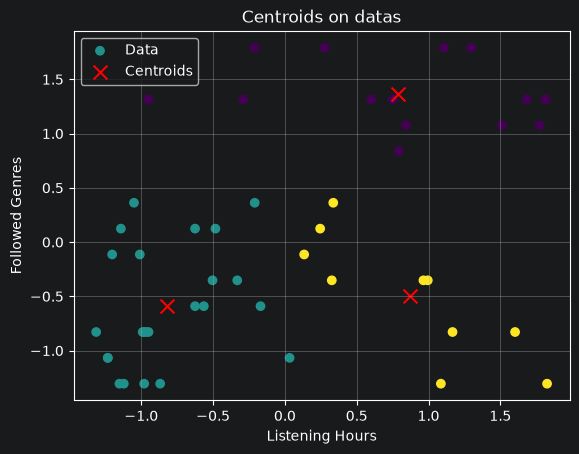

In [32]:

scaler = StandardScaler()

X_s = scaler.fit_transform(listener_data)

k_means = KMeans(n_clusters=3, random_state=42)
k_means.fit(X_s)
clusters = k_means.predict(X_s)
mean_c_0 =np.mean(listener_data[clusters == 0].to_numpy(),axis=0)
mean_c_1 =np.mean(listener_data[clusters == 1].to_numpy(),axis=0)
mean_c_2 =np.mean(listener_data[clusters == 2].to_numpy(),axis=0)
print(f"Centroid 0 Crazy listener: {mean_c_0[0]:.2f} | {int(mean_c_0[1])}\n{"-"*30}\
\nCentroid 1 Sometimes person: {mean_c_1[0]:.2f} | {int(mean_c_1[1])}\n{"-"*30}\n\
Centroid 2 Crazy about on gener: {mean_c_2[0]:.2f} | {int(mean_c_2[1])}\n{"-"*30}")

plt.scatter(X_s[:,0],X_s[:,1],c=clusters,label = "Data")
plt.scatter(
    k_means.cluster_centers_[:,0],
    k_means.cluster_centers_[:,1],
    c="red",s=100,marker="x",label="Centroids"
)
plt.legend()
plt.title("Centroids on datas")
plt.xlabel("Listening Hours")
plt.ylabel("Followed Genres")
plt.grid()
plt.show()



# Reason

In [33]:
# A) Answered by printing the mean of each cluster.

# B) K-means uses a random initialize, so if you run the algorithm again,
# the centroid locations might change.
# Also, the number of clusters doesn’t directly tell us about the quality of the clusters

# C) In Unsupervised Learning there are no anything as True Label ,
# and We need True and Predicted Label to measure Precision ,
# Recall, F1 or any Supervised metrics.

# D) If n_clusters = n_samples the model learned nothing from data Also if n_clusters = 1 model
# will not learn from data again becaues all samples will be members of 1 Centroid ,
# choose the right value for This HyperParameter is on The Distribution and shape of our data
# and some metrics like WCSS.

# Challenge-Last Question

In [34]:
smart_home_data = pd.DataFrame()

smart_home_data["temperature_c"] = [-0.6,40.7,17.7,6.4,20.0,8.4,35.5,-3.1,0.1,31.1,-2.6,31.5,-4.6,24.1,33.5,37.2,41.3,18.3,11.6,35.8,13.7,25.3,-4.0,33.0,15.2,21.3,31.6,13.9,37.7,25.5,29.2,31.6,11.5,-4.1,11.9,9.3,38.2,6.9,6.3,37.8,31.5,15.2,38.3,28.3,-1.6,10.1,34.7,24.9,23.9,33.0,24.9,7.6,13.1,11.2,4.4,7.2,26.6,34.9,4.5,31.2,34.1,20.3,12.5,4.5,3.8,10.2,-1.6,4.1,38.2,23.8,-3.2,7.9,29.0,38.9,13.7,28.7,33.3,-3.6,33.9,17.5,8.2,22.9,-2.0,2.9,20.1,22.4,5.6,30.1,31.0,11.6,23.0,41.0,8.6,24.4,10.0,38.4,16.8,35.4,3.6,8.3,8.2,22.1,18.1,30.5,-1.8,38.6,8,.5,20.8,19.8,18.1,39.7,23.7,14.6,15.6,6.1,41.1,30.4,8.7,8.7,29.0,18.7,-3.1,19.0,12.7,30.3,28.8,-1.4,3,5.4,-2.2,26.0,-1.8,27.9,12.6,4.6,32.1,41.1,23.7,17.6,18.6,-2.4,-2.4,6.5,0.3,13.7,4.8,21.9,20.7,-2.8,30.,1,-4.9,35.0,23.5,37.4,4.0,4.2,-0.5,11.0,22.2,-1.6,5.6,16.8,27.6,18.5,18.5,13.7,-1.1,25.1,19.8,6.0,34.2,5.5,37.8,39.3,17.9,27.0,32.9,10.2,7.2,-4.0,5.2,28.5,40.8,27.3,-3.1,32.6,6.8,4.8,4.8,22.1,-0.3,-3.7,10.4,27.5,3.3,39.7,24.3,-2.3,10.2,26.9,1.1,26.7,24.1,41.2,28.2,2.6,18.5,27.7,5.8,41.6,7.1,1.2,21.8,23.9,20,.2,21.8,6.8,-0.8,6.8,16.9,18.0,17.4,6.4,38.3,2.0,11.8,12.0,17.0,22.0,15.2,24.5,26.7,-4.0,18.0,-1.7,25.,4,32.0,38.5,12.8,20.1,29.2,7.4,21.8,28.8,3.3,15.1,21.7,38.0,26.0,10.6,24.5,26.7,3.3,17.7,2.3,40.5]
smart_home_data["household_size"] = [5,1,1,3,1,1,2,1,3,2,1,3,1,4,5,4,6,4,4,1,2,5,5,4,5,2,2,6,1,1,3,1,2,4,1,1,4,2,2,4,2,4,4,4,2,2,3,5,1,1,1,5,4,5,6,3,1,5,6,6,4,5,6,3,4,1,2,4,5,3,3,3,1,6,4,2,1,1,2,6,3,1,3,3,2,6,6,6,1,3,4,1,1,1,6,1,2,3,3,3,1,2,3,3,2,5,2,1,4,6,3,5,2,6,2,6,4,5,4,3,3,6,4,5,4,1,4,4,1,2,4,3,1,3,4,4,6,5,1,2,5,3,2,5,3,4,6,2,5,6,3,6,4,4,3,4,5,4,1,2,4,3,6,3,2,6,6,5,4,3,6,5,6,6,2,6,5,1,1,4,2,6,3,4,2,5,3,1,2,5,2,3,4,2,5,2,1,4,6,4,5,6,4,4,2,2,1,1,3,3,2,5,6,1,5,3,5,3,1,3,1,1,3,4,6,3,5,1,2,6,6,4,1,6,5,4,4,3,1,1,5,5,5,6,5,4,3,4,1,1,4,3,5,4,2,3,3,4,6,3]
smart_home_data["ac_units"] = [0,1,2,0,1,3,2,2,0,1,0,3,1,1,3,1,1,0,3,3,1,3,1,2,2,2,1,1,3,2,0,1,0,2,1,3,2,0,3,3,0,0,1,3,3,2,1,1,3,1,2,2,1,
3,0,2,2,2,3,3,1,3,3,3,1,2,1,1,0,1,3,1,2,0,2,0,2,0,1,1,3,2,3,0,2,2,2,2,0,0,2,0,2,0,0,0,2,0,0,1,2,1,3,1,0,3,
0,3,0,2,1,1,1,2,0,1,1,2,0,0,2,0,2,0,3,2,0,1,3,2,3,0,3,3,1,0,0,3,1,2,3,0,3,1,0,0,1,1,1,1,1,3,2,2,1,3,0,3,3,
0,1,1,2,3,0,0,2,0,3,0,1,1,0,3,1,3,0,1,0,0,3,2,3,1,2,0,1,3,1,0,0,0,3,0,2,1,0,1,1,3,1,3,1,3,2,3,3,1,2,1,3,3,
1,3,1,2,1,3,1,1,1,2,3,0,2,3,3,1,3,2,1,0,0,0,2,0,1,0,3,1,1,3,3,3,1,3,2,0,0,3,3,3,3,3,2,0,2,0,0,1]
smart_home_data["wiring_install_year"] = [2002,1988,2002,1983,1988,1976,1979,1985,2010,1979,1976,2006,1984,2012,2003,2018,1979,2020,1987,1996,1975,1994,1984,2006,2019,2004,1976,2023,2006,1985,1987,2001,1979,2016,1997,1981,1989,2013,1992,1989,1975,2011,1977,2020,2008,2001,2005,1985,2004,1979,1985,1989,1996,1989,1978,1993,2003,2018,1989,2015,1998,1983,2009,2005,2023,2002,1982,1989,2006,2006,2016,
1982,1988,2016,1990,2003,2002,2023,2021,2005,1984,1997,1982,1996,1975,2019,2015,1996,1981,1976,1999,2005,2005,2017,2013,2012,1996,2012,2002,2012,1975,1995,1989,2012,2006,1984,1988,1988,2005,1988,2012,1989,1980,1990,2011,1977,2018,1989,2000,1982,1975,2002,2013,1979,2011,2017,1987,2007,1998,1987,1984,1993,1979,1983,1994,2021,2004,1995,2002,1995,1982,2009,
1992,1991,2003,1989,1977,2003,1999,1986,2014,2022,1985,1984,2023,1987,1989,1981,2012,1992,2000,2003,2010,2009,2000,1995,2019,2011,2020,2003,1980,2020,1981,2004,2016,2012,2005,2000,2011,2016,2022,2023,2003,2001,1977,1979,2001,2005,1997,1988,2018,2019,1996,1979,1976,1986,2019,2018,2020,1995,1999,1992,1998,1975,1992,2012,1986,2002,2018,2006,1991,1984,1975,
1982,1990,1988,2003,1999,1982,1984,2015,2023,2007,2006,1997,2004,1980,2023,2004,1986,1989,1991,1987,1985,2001,2007,1976,2000,1976,1997,1983,2019,1989,2017,2013,2001,2018,2006,1985,1986,2007,1995,1996,2014,1998,2020,1997,1981,1994,2016]
smart_home_data["outage_risk"] = [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0]


display(smart_home_data.head())
display(smart_home_data.describe())
display(smart_home_data.info())

,temperature_c,household_size,ac_units,wiring_install_year,outage_risk
0,-0.600,5,0,2002,0
1,40.700,1,1,1988,0
2,17.700,1,2,2002,0
3,6.400,3,0,1983,0
4,20.000,1,1,1988,0


,temperature_c,household_size,ac_units,wiring_install_year,outage_risk
count,260.000,260.000,260.000,260.000,260.000
mean,17.317,3.369,1.473,"1,997.923",0.085
std,13.248,1.684,1.134,13.881,0.279
min,-4.900,1.000,0.000,"1,975.000",0.000
25%,5.950,2.000,0.000,"1,986.000",0.000
50%,17.800,3.000,1.000,"1,998.000",0.000
75%,27.975,5.000,3.000,"2,009.000",0.000
max,41.600,6.000,3.000,"2,023.000",1.000


<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature_c        260 non-null    float64
 1   household_size       260 non-null    int64  
 2   ac_units             260 non-null    int64  
 3   wiring_install_year  260 non-null    int64  
 4   outage_risk          260 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 10.3 KB


None

In [35]:
Xtrain,Xtest,ytrain,ytest = train_test_split(
    smart_home_data.iloc[:,:-1].to_numpy(),
    smart_home_data.iloc[:,-1].to_numpy(),
    random_state=42,
    stratify=smart_home_data.iloc[:,-1].to_numpy()
)

print(
f"Xtrain.shape {Xtrain.shape}\n\
ytrain.shape {ytrain.shape}\n\
Xtest.shape {Xtest.shape}\n\
ytest.shape {ytest.shape}"
)

Xtrain.shape (195, 4)
ytrain.shape (195,)
Xtest.shape (65, 4)
ytest.shape (65,)


In [36]:
# If we don't use stratify to keep ratio of classes in both train and test the same
# there is the risk of to change ratio between classes
# Scenario 1: model learn on a training set with wrong ratio like 0% of class 1 and 100 % of class 0
# Scenario 2: model learn on a acceptable training set
# but the ratio of classes in test set will be something like 0% of class 1 and 100 % of class 0
# and if the model does not learn to detect class 1 samples we will not find out because the accuracy will be 100
# and there is no any sample from class 1

In [37]:
# Base-line model
ypred_base = np.zeros_like(ytest)

cm = confusion_matrix(ytest, ypred_base)
TN,FP,FN,TP = cm.ravel()

base_precision = TP / (TP + FP + 1e-7)
base_recall = TP / (TP + FN + 1e-7)
base_f1 = 2 * ((base_precision * base_recall) / (base_precision + base_recall + 1e-7))
base_acc = (TP+TN) / (TP+TN+FP+FN+1e-7)

base_metrics_df = pd.DataFrame({
    "Precision": base_precision,
    "Recall": base_recall,
    "F1": base_f1,
    "Accuracy": int(base_acc*100),
},index=["Values"])


display(base_metrics_df.T)

,Values
Precision,0.000
Recall,0.000
F1,0.000
Accuracy,92.000


# Trees

In [38]:
tree_4= DecisionTreeClassifier(max_depth=4,random_state=42)
tree_4.fit(Xtrain,ytrain)
acc_train_4 = tree_4.score(Xtrain,ytrain)
acc_test_4 = tree_4.score(Xtest,ytest)

tree_nolimit = DecisionTreeClassifier(max_depth=None,random_state=42)
tree_nolimit.fit(Xtrain,ytrain)
ypred_nolimit = tree_nolimit.predict(Xtest)
acc_train_nolimit = tree_nolimit.score(Xtrain,ytrain)
acc_test_nolimit = tree_nolimit.score(Xtest,ytest)

tree_df = pd.DataFrame({
    "Train":[acc_train_4,acc_train_nolimit],
    "Test":[acc_test_4,acc_test_nolimit]
},index=["4","nolimit"])
tree_df.index.name = "MaxDepth"
tree_df
# nolimited model overfitted because train accuracy is 100 and test accuracy is 89%
# there is a big different between seen data and unseen data predicting

# Accuracy tell us the ratio between TP+TN / TOTAL  , So if the TN (majority class True classified) be very good
# we can't detect low TP (because it's minority class)
# but recall tell us the ratio between TP and TP+FN for target class
# precision tell us the ratio between TP and TP+FP for target class


,Train,Test
MaxDepth,,
4,0.949,0.938
nolimit,1.000,0.892


# Cross Validation K-fold

In [39]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores_stra = []
for train_idx,valid_idx in skf.split(Xtrain,ytrain):
    Xtrain_fold = Xtrain[train_idx,:-1]
    Xvalid_fold = Xtrain[valid_idx,:-1]
    ytrain_fold = ytrain[train_idx]
    yvalid_fold = ytrain[valid_idx]

    tree = DecisionTreeClassifier(random_state=42,max_depth=4)
    tree.fit(Xtrain_fold, ytrain_fold)

    y_pred = tree.predict(Xvalid_fold)
    recall = recall_score(yvalid_fold, y_pred)
    scores_stra.append(recall)

scores_stra_mean = np.mean(scores_stra)
scores_stra_std = np.std(scores_stra)

print(f"scores {scores_stra}")
print(f"mean {scores_stra_mean}")
print(f"std {scores_stra_std}")

scores [0.0, 0.0, 0.0, 0.25, 0.25]
mean 0.1
std 0.12247448713915891


In [40]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_kf = []

for train_idx, valid_idx in kf.split(Xtrain):

    Xtrain_fold = Xtrain[train_idx]
    Xvalid_fold = Xtrain[valid_idx]

    ytrain_fold = ytrain[train_idx]
    yvalid_fold = ytrain[valid_idx]

    tree = DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    )

    tree.fit(Xtrain_fold, ytrain_fold)

    y_pred = tree.predict(Xvalid_fold)

    scores_kf.append(recall_score(yvalid_fold, y_pred))

print("Fold recalls:", np.round(scores_kf,2))
print("Mean recall:", np.mean(scores_kf))
print("Std:", np.std(scores_kf))

Fold recalls: [0.25 0.33 0.   0.   0.33]
Mean recall: 0.1833333333333333
Std: 0.15275252316519466


In [41]:
result_kfold = pd.DataFrame()
result_kfold["stratified"] = [scores_stra_mean,scores_stra_std]
result_kfold["Kfold"] = [np.mean(scores_kf),np.std(scores_kf)]
result_kfold.index = ["mean","std"]
result_kfold

,stratified,Kfold
mean,0.100,0.183
std,0.122,0.153


In [42]:
tree = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=tree,
    param_grid={
        "max_depth":[4,5,6,1],
        },
    cv=skf,
    scoring="recall",
    )

grid_search.fit(Xtrain,ytrain)
best_model = grid_search.best_estimator_
print(f"best params {grid_search.best_params_}")
print(f"best recall score {grid_search.best_score_}")
best_pred = best_model.predict(Xtest)

best params {'max_depth': 5}
best recall score 0.35


absolutly cross validation is best way to evaluate models because the output score is mean of unseen data score 
so we say with more confidence that our model how well work on unseen datas